## Computer Vision - Aufgabe 3: Image Stitching

### Einlesen der Bilder

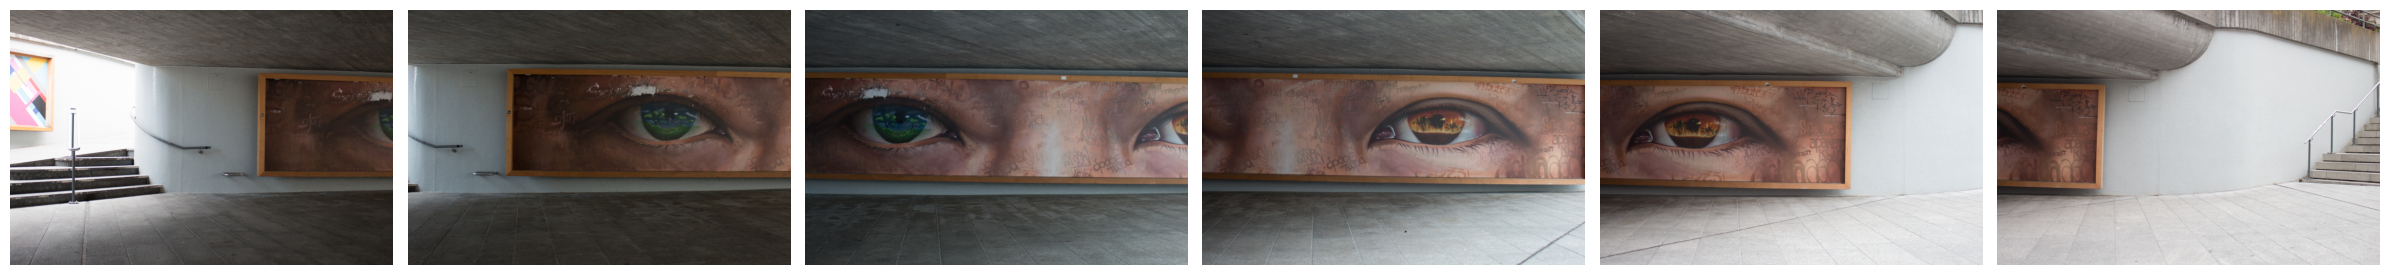

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from pathlib import Path
import cv2

setname = "Set2"
images = []

for file in Path("Bilder").glob(f"{setname}*"):
    image = plt.imread(file)
    image = image.astype(float)
    image = image / 255
    images.append(image)

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))

# Falls nur ein Bild vorhanden ist:
if len(images) == 1:
    axes = [axes]

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Definition der Passpunkte

In [ ]:
# Bildkoordinaten
bi1 = np.array([
    [451, 365],
    [520, 169],
    [611, 434],
    [667, 181],
    [665, 422],
    [893, 296],
])

bi2 = np.array([
    [276, 169],
    [272, 418],
    [522, 290],
    [743, 251],
    [822, 324],
    [910, 422]
])

bi3 = np.array([
    [312, 259],
    [392, 333],
    [484, 435],
    [675, 187],
    [859, 357],
    [981, 438]
])

bi4 = np.array([
    [243, 183],
    [433, 359],
    [559, 436],
    [615, 292],
    [814, 193],
    [941, 401]
])

bi5 = np.array([
    [244, 302],
    [435, 201],
    [575, 411],
    [637, 452],
    [657, 189],
    [751, 234]
])

bi6 = np.array([
    [255, 452],
    [281, 198],
    [384, 240],
    [417, 185],
    [423, 484],
    [565, 55]
])

oi1 = np.array([
    [0.5, 2.5],
    [0.7, 1.1],
    [1.0, 2.8],
    [1.2, 1.2],
    [1.25, 2.75],
    [2.2, 1.95]
])

oi2 = np.array([
    [1.2, 1.2],
    [1.25, 2.75],
    [2.2, 1.95],
    [2.9, 1.70],
    [3.2, 2.05],
    [3.5, 2.75]
])

oi3 = np.array([
    [2.9, 1.70],
    [3.2, 2.05],
    [3.5, 2.75],
    [4.6, 1.2],
    [5.5, 2.1],
    [5.9, 2.75]
])

oi4 = np.array([
    [4.6, 1.2],
    [5.5, 2.1],
    [5.9, 2.75],
    [6.1, 1.95],
    [7.1, 1.2],
    [7.7, 2.5]
])

oi5 = np.array([
    [6.1, 1.95],
    [7.1, 1.2],
    [7.7, 2.5],
    [7.95, 2.75],
    [8.05, 1.1],
    [8.45, 1.4]
])

oi6 = np.array([
    [7.95, 2.75],
    [8.05, 1.1],
    [8.45, 1.4],
    [8.6, 1.0],
    [8.65, 2.9],
    [9.3, 0.0]
])

### Anzeigen der Bildpunkte

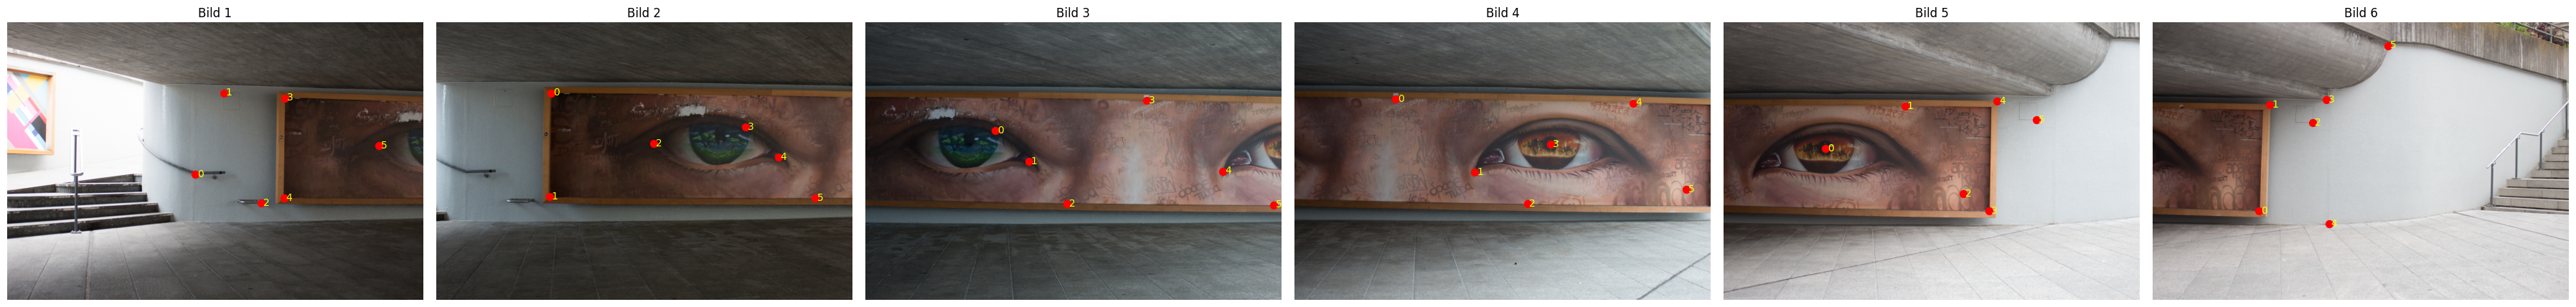

In [31]:
points = [bi1, bi2, bi3, bi4, bi5, bi6]

fig, axes = plt.subplots(1, len(images),
                         figsize=(6 * len(images), 6))

# Falls nur 1 Bild vorhanden
if len(images) == 1:
    axes = [axes]

for idx, (img, bi) in enumerate(zip(images, points)):

    axes[idx].imshow(img)

    # Passpunkte
    axes[idx].scatter(
        bi[:,0],
        bi[:,1],
        c='red',
        s=50
    )

    # Nummerierung
    for i, (x, y) in enumerate(bi):

        axes[idx].text(
            x + 5,
            y + 5,
            str(i),
            color='yellow'
        )

    axes[idx].set_title(f"Bild {idx+1}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### Berechnung der projektiven Entzerrung

In [36]:
def compute_rectification(bi, oi):
    A = []
    for i in range(len(oi)):
        x, y = bi[i]
        u, v = oi[i]
        A.append([x, y, 1, 0, 0, 0, -(u*x), -(u*y)])
        A.append([0, 0, 0, x, y, 1, -(v*x), -(v*y)])
    A = np.array(A)

    x = oi.flatten()
    h = np.linalg.pinv(A) @ x
    H = np.array([
        [h[0], h[1], h[2]],
        [h[3], h[4], h[5]],
        [h[6], h[7], 1]
    ])
    return H

# scaling factor for world coordinates
SCALE = 100

oi1_scaled = oi1 * SCALE
oi2_scaled = oi2 * SCALE
oi3_scaled = oi3 * SCALE
oi4_scaled = oi4 * SCALE
oi5_scaled = oi5 * SCALE
oi6_scaled = oi6 * SCALE

H1 = compute_rectification(bi1, oi1_scaled)
H2 = compute_rectification(bi2, oi2_scaled)
H3 = compute_rectification(bi3, oi3_scaled)
H4 = compute_rectification(bi4, oi4_scaled)
H5 = compute_rectification(bi5, oi5_scaled)
H6 = compute_rectification(bi6, oi6_scaled)


### Berechnung der Panorama-Größe

In [37]:
h, w = images[0].shape[:2]

corners = np.array([
    [0, 0],
    [w, 0],
    [w, h],
    [0, h]
], dtype=np.float32)

corners1_t = cv2.perspectiveTransform(
    corners.reshape(-1,1,2),
    H1
)

corners2_t = cv2.perspectiveTransform(
    corners.reshape(-1,1,2),
    H2
)

corners3_t = cv2.perspectiveTransform(
    corners.reshape(-1,1,2),
    H3
)

corners4_t = cv2.perspectiveTransform(
    corners.reshape(-1,1,2),
    H4
)

corners5_t = cv2.perspectiveTransform(
    corners.reshape(-1,1,2),
    H5
)

corners6_t = cv2.perspectiveTransform(
    corners.reshape(-1,1,2),
    H6
)

all_corners = np.concatenate([
    corners1_t,
    corners2_t,
    corners3_t,
    corners4_t,
    corners5_t,
    corners6_t
], axis=0)

xs = all_corners[:,0,0]
ys = all_corners[:,0,1]

xmin = np.min(xs)
xmax = np.max(xs)

ymin = np.min(ys)
ymax = np.max(ys)

PAN_WIDTH = int(np.ceil(xmax - xmin))
PAN_HEIGHT = int(np.ceil(ymax - ymin))

tx = -xmin
ty = -ymin

T = np.array([
    [1,0,tx],
    [0,1,ty],
    [0,0,1]
])

H1_shifted = T @ H1
H2_shifted = T @ H2
H3_shifted = T @ H3
H4_shifted = T @ H4
H5_shifted = T @ H5
H6_shifted = T @ H6

Hs_shifted = [
    H1_shifted,
    H2_shifted,
    H3_shifted,
    H4_shifted,
    H5_shifted,
    H6_shifted
]

### Anwendung der projektiven Entzerrung und Berechnung der Gewichte

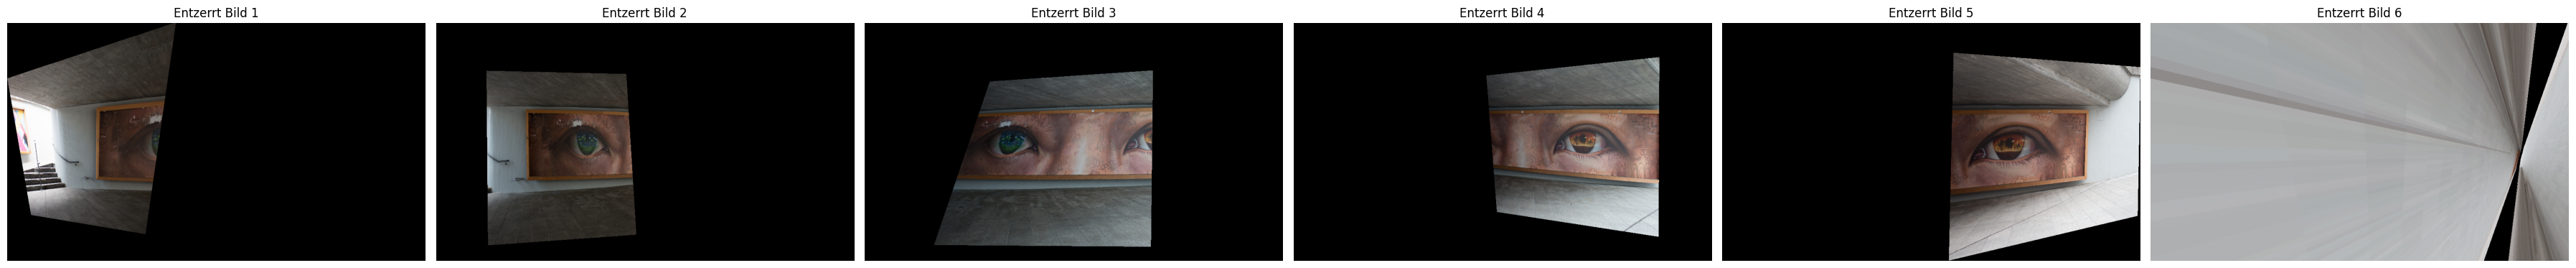

In [38]:
def compute_weights(height, width):

    weights = np.zeros((height, width), dtype=np.float32)

    for y in range(height):
        for x in range(width):

            wx = 1 - (2 / width) * abs(x - width / 2)
            wy = 1 - (2 / height) * abs(y - height / 2)

            weights[y, x] = wx * wy

    return weights


def image_rectification(image, H, out_h, out_w):

    H_inv = np.linalg.inv(H)

    # Graubild oder RGB?
    if len(image.shape) == 2:
        rectified = np.zeros((out_h, out_w),
                             dtype=image.dtype)
    else:
        rectified = np.zeros((out_h, out_w, image.shape[2]),
                             dtype=image.dtype)

    for y_ref in range(out_h):
        for x_ref in range(out_w):

            p_ref = np.array([x_ref, y_ref, 1])

            p_img = H_inv @ p_ref
            p_img /= p_img[2]

            x = p_img[0]
            y = p_img[1]

            x_n = int(np.round(x))
            y_n = int(np.round(y))

            if (0 <= x_n < image.shape[1] and
                0 <= y_n < image.shape[0]):

                rectified[y_ref, x_ref] = image[y_n, x_n]

    return rectified


weights_all = []
weights_rect_all = []
rectified_images = []

for img, H in zip(images, Hs_shifted):

    h, w = img.shape[:2]

    # Gewichte
    weights = compute_weights(h, w)
    weights_all.append(weights)

    # Bild entzerren
    rectified = image_rectification(img, H, PAN_HEIGHT, PAN_WIDTH)
    rectified_images.append(rectified)

    # Gewichte entzerren
    weights_rect = image_rectification(weights, H, PAN_HEIGHT, PAN_WIDTH)
    weights_rect_all.append(weights_rect)


fig, axes = plt.subplots(1, len(rectified_images), figsize=(6 * len(rectified_images), 7))

# Falls nur 1 Bild
if len(rectified_images) == 1:
    axes = [axes]

for idx, rectified in enumerate(rectified_images):

    axes[idx].imshow(rectified)

    axes[idx].set_title(
        f"Entzerrt Bild {idx+1}"
    )

    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### Panorama erzeugen

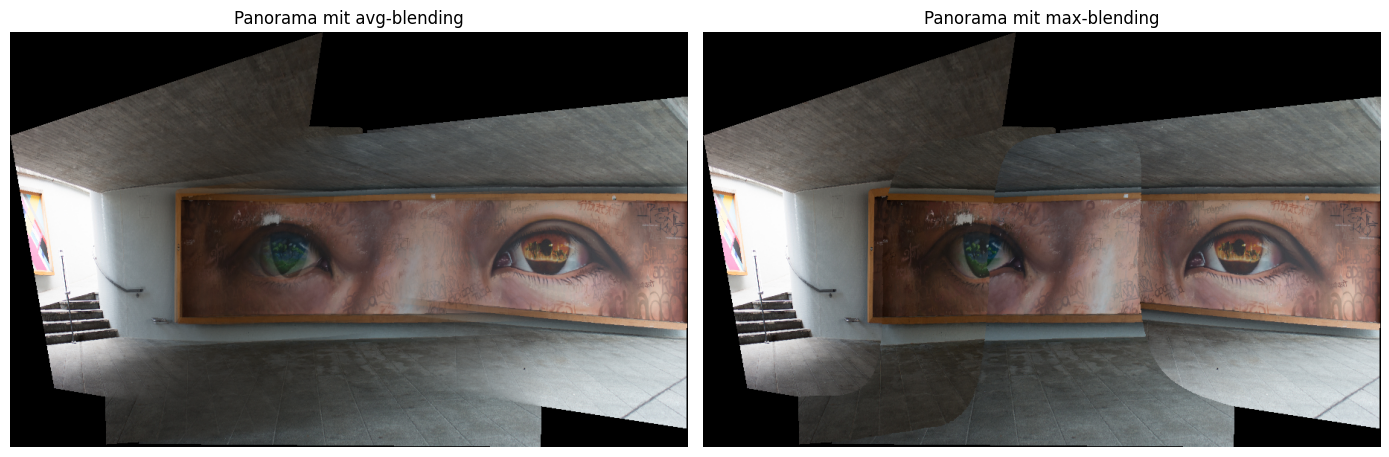

In [21]:
def blend_images(img1,
                 img2,
                 weights1,
                 weights2,
                 mode="average"):

    h, w = img1.shape[:2]

    output = np.zeros_like(img1, dtype=np.float32)

    for y in range(h):
        for x in range(w):

            p1 = img1[y, x].astype(np.float32)
            p2 = img2[y, x].astype(np.float32)

            w1 = weights1[y, x]
            w2 = weights2[y, x]

            valid1 = np.sum(p1) > 0
            valid2 = np.sum(p2) > 0

            if valid1 and not valid2:

                output[y, x] = p1

            elif valid2 and not valid1:

                output[y, x] = p2

            elif valid1 and valid2:

                if mode == "max":

                    if w1 > w2:
                        output[y, x] = p1
                    else:
                        output[y, x] = p2

                elif mode == "average":

                    denom = w1 + w2 + 1e-8

                    output[y, x] = (
                        w1 * p1 + w2 * p2
                    ) / denom

    return output

panorama_avg = rectified_images[0]
panorama_max = rectified_images[0]
panorama_weights = weights_rect_all[0]

for i in range(1, len(rectified_images)):

    panorama_avg = blend_images(
        panorama_avg,
        rectified_images[i],
        panorama_weights,
        weights_rect_all[i],
        mode="average"
    )

    panorama_max = blend_images(
        panorama_max,
        rectified_images[i],
        panorama_weights,
        weights_rect_all[i],
        mode="max"
    )

    panorama_weights = np.maximum(
        panorama_weights,
        weights_rect_all[i]
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(panorama_avg)
axes[0].set_title("Panorama mit avg-blending")
axes[0].axis("off")
axes[1].imshow(panorama_max)
axes[1].set_title("Panorama mit max-blending")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Mutliband-Blending

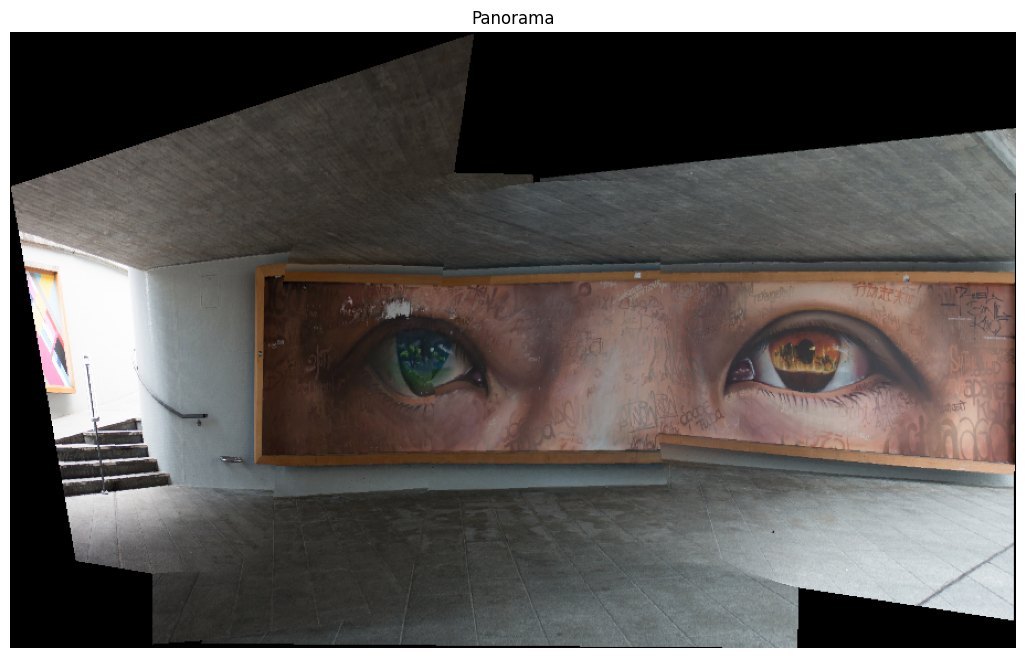

In [22]:
# TODO: Aufgabe d) Panorama über Hochpass und Tiefpass erzeugen
def blend_images_mb(img1,
                    img2,
                    weights1,
                    weights2,
                    mode="average"):

    h, w = img1.shape[:2]
    output = np.zeros_like(img1, dtype=np.float32)

    for y in range(h):
        for x in range(w):

            p1 = img1[y, x].astype(np.float32)
            p2 = img2[y, x].astype(np.float32)

            w1 = weights1[y, x]
            w2 = weights2[y, x]

            # Hochpassbilder können auch negative Werte haben, daher max mit 0
            w1 = max(w1, 0.0)
            w2 = max(w2, 0.0)

            denom = w1 + w2 + 1e-8

            if mode == "average":
                output[y, x] = (w1 * p1 + w2 * p2) / denom

            elif mode == "max":
                output[y, x] = p1 if w1 > w2 else p2

    return output

def lowpass(image, ksize=21, sigma=5):

    return cv2.GaussianBlur(
        image.astype(np.float32),
        (ksize, ksize),
        sigma
    )

def highpass(image, low):

    high = image.astype(np.float32) - low

    return high

def multiband_blend(
    img1,
    img2,
    weights1,
    weights2,
    ksize=21,
    sigma=5
):

    low1 = lowpass(img1, ksize, sigma)
    low2 = lowpass(img2, ksize, sigma)

    high1 = highpass(img1, low1)
    high2 = highpass(img2, low2)

    low_blend = blend_images_mb(low1, low2, weights1, weights2, mode="average")
    high_blend = blend_images_mb(high1, high2, weights1, weights2, mode="max")

    result = low_blend + high_blend
    # Hier nicht uint8, da Hochpassbilder auch negative Werte haben können
    return np.clip(result, 0, 255)

panorama_mb = rectified_images[0]
panorama_weights_mb = weights_rect_all[0]
for i in range(1, len(rectified_images)):

    panorama_mb = multiband_blend(
        panorama_mb,
        rectified_images[i],
        panorama_weights_mb,
        weights_rect_all[i],
        ksize=21,
        sigma=5
    )

    panorama_weights_mb = np.maximum(
        panorama_weights_mb,
        weights_rect_all[i]
    )
    
plt.figure(figsize=(14,8))
plt.imshow(panorama_mb)
plt.axis("off")
plt.title("Panorama")
plt.show()


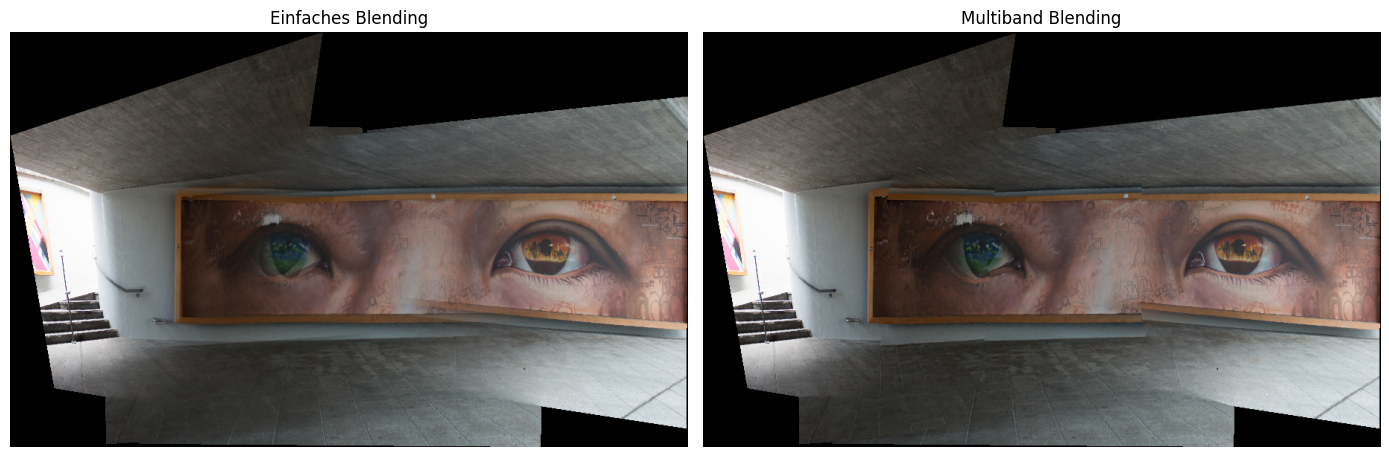

In [23]:
# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(panorama_avg)
axes[0].set_title("Einfaches Blending")
axes[0].axis("off")
axes[1].imshow(panorama_mb)
axes[1].set_title("Multiband Blending")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Gleicher Versuch auf anderem Set

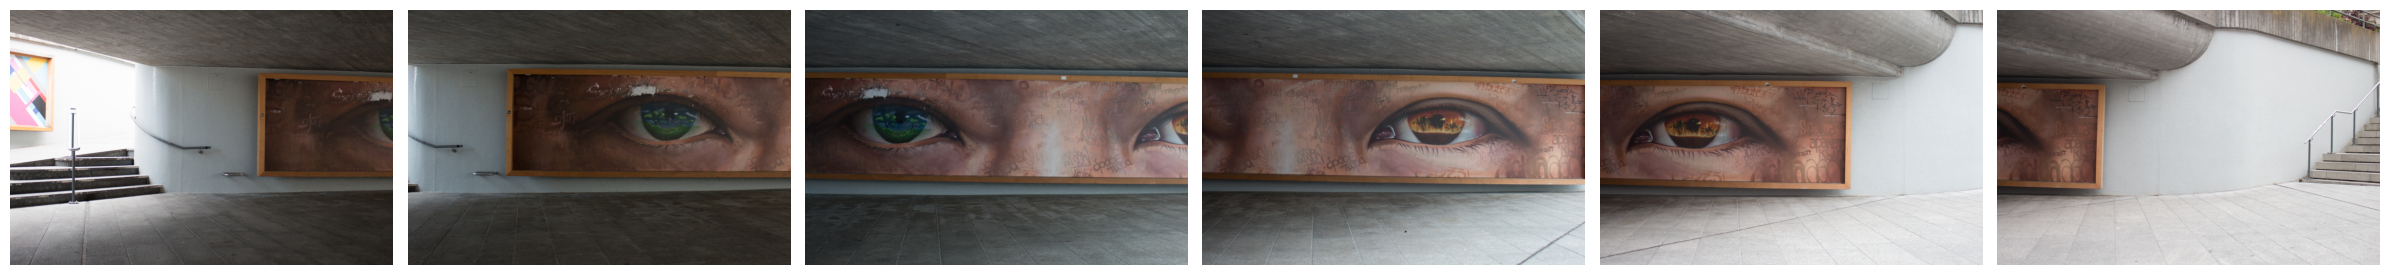

In [24]:
setname = "Set2"
images = []

for file in Path("Bilder").glob(f"{setname}*"):
    image = plt.imread(file)
    image = image.astype(float)
    image = image / 255
    images.append(image)

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))

# Falls nur ein Bild vorhanden ist:
if len(images) == 1:
    axes = [axes]

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Definition der Passpunkte

In [25]:
# Bildkoordinaten
bi1 = np.array([
    [451, 365],
    [520, 169],
    [611, 434],
    [667, 181],
    [665, 422],
    [893, 296],
])

bi2 = np.array([
    [272, 418],
    [276, 169],
    [522, 290],
    [743, 251],
    [822, 324],
    [910, 422]
])

bi3 = np.array([
    [312, 259],
    [392, 333],
    [484, 435]
])

bi4 = np.array([
    [264, 83], # Fenster 4 oben - Mitte - Überlappung Bild 3
    [425, 35], # Fenster 5 oben - Ecke oben rechts - Überlappung Bild 3
    [391, 443], # Fenster 5 unten - Mitte unten - Überlappung Bild 3
    [421, 351], # Fenster 5 unten - Mitte Kante rechts
    [625, 174], # Fenster 6 oben - Ecke unten rechts
    [585, 353] # Fenster 6 unten - Mitte
])

# Weltkoordinaten
oi1 = np.array([
    [1.7, 3.5], # Fenster unten links, Mitte
    [1.25, 7.5], # Fenster oben links, Mitte
    [5.7, 0.0], # Tür Mitte unten - Überlappung Bild 2
    [4.5, 4.2], # Gesicht Nase Tür links - Überlappung Bild 2
    [7.2, 4.2], # Gesicht Nase Tür rechts - Überlappung Bild 2
    [9.0, 3.8] # Fenster unten rechts, Mitte - Überlappung Bild 2
])

oi2 = np.array([
    [5.7, 0.0], # Tür Mitte unten - Überlappung Bild 1
    [4.5, 4.2], # Gesicht Nase Tür links - Überlappung Bild 1
    [7.2, 4.2], # Gesicht Nase Tür rechts - Überlappung Bild 1
    [9.0, 3.8], # Fenster 2 unten - Mitte - Überlappung Bild 1
    [11.2, 2.6], # Lampe Fenster
    [12.2, 4.6] # Fenster 3 unten - oben Mitte
])

oi3 = np.array([
    [9.0, 3.8], # Fenster 2 unten - Mitte - Überlappung Bild 2
    [11.2, 2.6], # Lampe Fenster - Überlappung Bild 2
    [12.2, 4.6], # Fenster 3 unten - oben Mitte - Überlappung Bild 2
    [14.3, 8.0], # Fenster 4 oben - Mitte - Überlappung Bild 4
    [16.9, 8.7], # Fenster 5 oben - Ecke oben rechts - Überlappung Bild 4 
    [16.5, 2.3] # Fenster 5 unten - Mitte unten - Überlappung Bild 4
])

oi4 = np.array([
    [14.3, 8.0], # Fenster 4 oben - Mitte - Überlappung Bild 3
    [16.9, 8.7], # Fenster 5 oben - Ecke oben rechts - Überlappung Bild 3 
    [16.5, 2.3], # Fenster 5 unten - Mitte unten - Überlappung Bild 3
    [17.0, 3.7], # Fenster 5 unten - Mitte Kante rechts
    [20.2, 6.3], # Fenster 6 oben - Ecke unten rechts
    [19.6, 3.7] # Fenster 6 unten - Mitte
])
